# Resident wellbeing: predicting next month

**Minimal setup:** this notebook plus a **`data/`** folder. The next code cell uses **`./data`** if it exists under Jupyter’s current working directory, otherwise **`../data`**. Easiest layout: keep **`data/`** and this **`.ipynb`** in the **same folder** and start Jupyter with that folder as the working directory.

### In plain terms: what is this notebook doing?
We build a **table**: one row per girl per month. Inputs are **that month** (visits, sessions, school, etc.) plus **her wellbeing score that same month**. The computer tries to guess **her wellbeing the following month**.  
That guess is **not magic** — it is **curve-fitting** on past rows: find patterns that matched history, then apply them to new rows. Two algorithms do this: a **straight-line model** (easy to read) and a **random forest** (more flexible, often better at guessing).

---

## 1. Problem Framing

### Business question

Who among residents may have **lower holistic wellbeing next month**, so case managers can prioritize support before problems deepen?


**Main job:** Flag girls who might have **lower wellbeing next month** so staff can plan support.

- **Random forest:** tuned for **accurate guesses** on data the model has not seen (time-based test + validation that keeps whole girls together).
- **Linear regression:** for **discussion only** — which direction each factor tends to go with next month’s score. It does **not** prove what *caused* a change.

**Score we predict:** One number: the **average** of health, sleep, food, and energy (~1–5 each), computed in the code that loads `health_wellbeing_records`.

**Why it matters:** Miss a drop in wellbeing and someone may not get help; cry wolf too often and staff stop trusting the tool.

**How we check the model:** We save **later months** and only score the model on those (MAE, RMSE, R²). Even if exact guesses are fuzzy, a good **ordering** (who is likely lowest) can still help staff.

**No cheating the timeline:** We only use **month *m*** (and fixed background) to predict **month *m*+1**. We never feed in future health rows.

### Predictive and Explanatory Modeling Map

This notebook includes **both** modeling lenses:

- **Predictive modeling** (for future-month forecasting):
  - Tuned Random Forest model used for out-of-sample prediction performance
  - Main predictive validation appears in the evaluation section and business readout

- **Explanatory modeling** (for relationship interpretation):
  - Linear Regression model used to interpret directional associations
  - Coefficient-focused interpretation appears in the causal/relationship analysis section

In short: **Random Forest = predictive forecasting**, **Linear Regression = explanatory interpretation**.

## 2. Data Acquisition, Preparation & Exploration

**Data files:** health/wellbeing; counseling, visits, school, plans, incidents; resident and safehouse info. (No donor or social tables here.)

**How a row is made:** (1) Count or average things per **girl + calendar month**. (2) Keep rows only if we also have wellbeing **next** month — that next-month score is what we predict. (3) Add each girl’s fixed background (house, case type, etc.).

**Pipelines:** sklearn chains **fill missing values → scale or encode → model** so training and any later deployment run the same steps.

**Code next:** load CSVs, merge into one table, then quick plots and correlations.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns

    sns.set_theme(style="whitegrid")
except ImportError:
    sns = None

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

_cwd = Path.cwd()
if (_cwd / "data").is_dir():
    DATA_DIR = _cwd / "data"
elif (_cwd.parent / "data").is_dir():
    DATA_DIR = _cwd.parent / "data"
else:
    raise FileNotFoundError(
        "Could not find data/: set Jupyter’s cwd so ./data or ../data exists "
        "(see opening markdown)."
    )


def rmse(y_true, y_pred):
    # sklearn >= 1.4 removed mean_squared_error(..., squared=False); sqrt(MSE) is equivalent
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


In [2]:
def to_year_month(df: pd.DataFrame, col: str) -> pd.DataFrame:
    out = df.copy()
    out["_dt"] = pd.to_datetime(out[col], errors="coerce")
    out["ym"] = out["_dt"].dt.to_period("M")
    return out.drop(columns=["_dt"])


# --- Health: one row per resident-month
health_raw = pd.read_csv(DATA_DIR / "health_wellbeing_records.csv")
health = to_year_month(health_raw, "record_date")
# Composite wellbeing — mean of four ~1–5 subscores (not general health alone)
health["wellbeing"] = health[
    [
        "general_health_score",
        "sleep_quality_score",
        "nutrition_score",
        "energy_level_score",
    ]
].mean(axis=1)
health_month = health.groupby(["resident_id", "ym"], as_index=False).agg(
    wellbeing=("wellbeing", "mean"),
    record_date=("record_date", "min"),
)

# Target: wellbeing in month m+1; features use month m (includes wellbeing_lag)
hm = health_month.sort_values(["resident_id", "ym"])
fwd = hm[["resident_id", "ym", "wellbeing"]].copy()
fwd["ym"] = fwd["ym"] + 1
fwd = fwd.rename(columns={"wellbeing": "wellbeing_next"})
panel = hm.merge(fwd, on=["resident_id", "ym"], how="inner")
panel = panel.rename(columns={"wellbeing": "wellbeing_lag"})
print("Panel:", panel.shape, "= one row per girl-month where we know this month and next month’s wellbeing.")
panel.head()


Panel: (474, 5) = one row per girl-month where we know this month and next month’s wellbeing.


,resident_id,ym,wellbeing_lag,record_date,wellbeing_next
0,1,2023-11,3.0375,2023-11-01,3.0475
1,1,2023-12,3.0975,2023-12-01,3.0375
2,1,2024-01,3.1200,2024-01-01,3.0975
3,1,2024-02,3.1550,2024-02-01,3.1200
4,1,2024-03,3.1800,2024-03-01,3.1550


In [3]:
# --- process_recordings (month m)
pr = pd.read_csv(DATA_DIR / "process_recordings.csv")
for c in ["progress_noted", "concerns_flagged", "referral_made"]:
    if pr[c].dtype == object:
        pr[c] = pr[c].map(lambda x: str(x).lower() in ("true", "1", "yes"))
    pr[c] = pr[c].astype(bool)
pr = to_year_month(pr, "session_date")
neg_end = {"Distressed", "Withdrawn", "Sad", "Angry", "Anxious"}
pr["negative_end"] = pr["emotional_state_end"].isin(neg_end).astype(int)
pr_feats = pr.groupby(["resident_id", "ym"], as_index=False).agg(
    n_sessions=("recording_id", "count"),
    total_session_minutes=("session_duration_minutes", "sum"),
    mean_session_minutes=("session_duration_minutes", "mean"),
    n_session_workers=("social_worker", "nunique"),
    share_negative_end=("negative_end", "mean"),
    share_progress_noted=("progress_noted", "mean"),
    share_concerns=("concerns_flagged", "mean"),
    share_referral=("referral_made", "mean"),
)

# --- home_visitations
hv = pd.read_csv(DATA_DIR / "home_visitations.csv")
for c in ["safety_concerns_noted", "follow_up_needed"]:
    if hv[c].dtype == object:
        hv[c] = hv[c].map(lambda x: str(x).lower() in ("true", "1", "yes"))
    hv[c] = hv[c].astype(bool)
hv = to_year_month(hv, "visit_date")
hv_feats = hv.groupby(["resident_id", "ym"], as_index=False).agg(
    n_visits=("visitation_id", "count"),
    share_safety_concern=("safety_concerns_noted", "mean"),
    share_follow_up_needed=("follow_up_needed", "mean"),
    n_visit_workers=("social_worker", "nunique"),
)

# --- education_records (CSV schema)
edu = pd.read_csv(DATA_DIR / "education_records.csv")
edu = to_year_month(edu, "record_date")
edu_feats = edu.groupby(["resident_id", "ym"], as_index=False).agg(
    n_edu_rows=("education_record_id", "count"),
    mean_attendance_rate=("attendance_rate", "mean"),
    mean_progress_percent=("progress_percent", "mean"),
)

# --- incidents
inc = pd.read_csv(DATA_DIR / "incident_reports.csv")
sev_map = {"Low": 1, "Medium": 2, "High": 3}
inc["severity_ord"] = inc["severity"].map(sev_map)
inc = to_year_month(inc, "incident_date")
inc_feats = inc.groupby(["resident_id", "ym"], as_index=False).agg(
    n_incidents=("incident_id", "count"),
    max_severity=("severity_ord", "max"),
    mean_severity=("severity_ord", "mean"),
)

# --- intervention plan touches in month m
ip = pd.read_csv(DATA_DIR / "intervention_plans.csv")
ip["created_ym"] = pd.to_datetime(ip["created_at"], errors="coerce").dt.to_period("M")
ip["updated_ym"] = pd.to_datetime(ip["updated_at"], errors="coerce").dt.to_period("M")
rows = []
for _, r in ip.iterrows():
    rid = r["resident_id"]
    for label, ym in [("created", r["created_ym"]), ("updated", r["updated_ym"])]:
        if pd.isna(ym):
            continue
        rows.append((rid, ym, label))
touch = pd.DataFrame(rows, columns=["resident_id", "ym", "kind"])
ip_feats = touch.groupby(["resident_id", "ym"], as_index=False).agg(
    intervention_touches=("kind", "count"),
    intervention_created=("kind", lambda s: (s == "created").sum()),
    intervention_updated=("kind", lambda s: (s == "updated").sum()),
)

# --- residents + safehouses (static)
res = pd.read_csv(DATA_DIR / "residents.csv")
sh = pd.read_csv(DATA_DIR / "safehouses.csv")
risk_map = {"Low": 1, "Medium": 2, "High": 3, "Critical": 4}
res["initial_risk_ord"] = res["initial_risk_level"].map(risk_map)
res["current_risk_ord"] = res["current_risk_level"].map(risk_map)
bool_cols = [
    c
    for c in res.columns
    if c.startswith("sub_cat_") or c.startswith("family_") or c in ("is_pwd", "has_special_needs")
]
for c in bool_cols:
    if res[c].dtype == object:
        res[c] = res[c].map(lambda x: str(x).lower() in ("true", "1", "yes"))
    res[c] = res[c].fillna(False).astype(bool)
static = res[
    ["resident_id", "safehouse_id", "case_status", "case_category", "initial_risk_ord", "current_risk_ord"]
    + bool_cols
].merge(
    sh[["safehouse_id", "region", "capacity_girls", "current_occupancy"]],
    on="safehouse_id",
    how="left",
)
static["occupancy_ratio"] = static["current_occupancy"] / static["capacity_girls"].replace(0, np.nan)
print("Done summing visits, sessions, school, etc. by girl-month. Next cell joins everything into one table.")


Done summing visits, sessions, school, etc. by girl-month. Next cell joins everything into one table.


In [4]:
# --- Master table (feature month m)
df = panel.merge(pr_feats, on=["resident_id", "ym"], how="left")
df = df.merge(hv_feats, on=["resident_id", "ym"], how="left")
df = df.merge(edu_feats, on=["resident_id", "ym"], how="left")
df = df.merge(inc_feats, on=["resident_id", "ym"], how="left")
df = df.merge(ip_feats, on=["resident_id", "ym"], how="left")
df = df.merge(static, on="resident_id", how="left")

fill_zero = [
    "n_sessions",
    "total_session_minutes",
    "mean_session_minutes",
    "n_session_workers",
    "n_visits",
    "n_visit_workers",
    "n_edu_rows",
    "n_incidents",
    "intervention_touches",
    "intervention_created",
    "intervention_updated",
]
for c in fill_zero:
    if c in df.columns:
        df[c] = df[c].fillna(0)
for c in [
    "share_negative_end",
    "share_progress_noted",
    "share_concerns",
    "share_referral",
    "share_safety_concern",
    "share_follow_up_needed",
    "mean_attendance_rate",
    "mean_progress_percent",
    "max_severity",
    "mean_severity",
]:
    if c in df.columns:
        df[c] = df[c].fillna(0)

df = df.dropna(subset=["wellbeing_next", "safehouse_id"])
print("Full table:", df.shape[0], "rows,", df.shape[1], "columns — each row is one girl-month ready for the models.")
df.head()


Full table: 474 rows, 52 columns — each row is one girl-month ready for the models.


,resident_id,ym,wellbeing_lag,record_date,wellbeing_next,n_sessions,total_session_minutes,mean_session_minutes,n_session_workers,share_negative_end,...,has_special_needs,family_is_4ps,family_solo_parent,family_indigenous,family_parent_pwd,family_informal_settler,region,capacity_girls,current_occupancy,occupancy_ratio
0,1,2023-11,3.0375,2023-11-01,3.0475,3.0,222.0,74.000000,3.0,0.333333,...,True,False,False,False,False,False,Visayas,12,12,1.0
1,1,2023-12,3.0975,2023-12-01,3.0375,6.0,452.0,75.333333,5.0,0.000000,...,True,False,False,False,False,False,Visayas,12,12,1.0
2,1,2024-01,3.1200,2024-01-01,3.0975,3.0,182.0,60.666667,3.0,0.333333,...,True,False,False,False,False,False,Visayas,12,12,1.0
3,1,2024-02,3.1550,2024-02-01,3.1200,3.0,133.0,44.333333,2.0,0.000000,...,True,False,False,False,False,False,Visayas,12,12,1.0
4,1,2024-03,3.1800,2024-03-01,3.1550,5.0,357.0,71.400000,4.0,0.200000,...,True,False,False,False,False,False,Visayas,12,12,1.0


### Key feature definitions *(for Section 2 in this notebook — Data Acquisition, Preparation & Exploration)*

**One row:** one `resident_id` in one **calendar month** *m* (the input month). We predict wellbeing in month *m*+1. A row exists only if **both** months have a health/wellbeing record (so the target is never missing by construction for modeling rows).

**Composite wellbeing score:** **Mean** of `general_health_score`, `sleep_quality_score`, `nutrition_score`, and `energy_level_score` from `health_wellbeing_records` (each component is typically ~1–5).

| Column | Meaning |
| :--- | :--- |
| `wellbeing_next` | **Target:** composite wellbeing in month *m*+1. |
| `wellbeing_lag` | Composite wellbeing in month *m* (same formula); often the strongest predictor because wellbeing is persistent month to month. |

**Education (`education_records`, aggregated to girl × month *m*):**

| Feature | Meaning |
| :--- | :--- |
| `n_edu_rows` | Count of education rows for that girl in month *m* (multiple subjects/entries possible). |
| `mean_attendance_rate` | Mean of `attendance_rate` across those rows (0–1 or percent depending on CSV encoding; interpret as “average attendance where recorded”). |
| `mean_progress_percent` | Mean of `progress_percent` across those rows (staff judgment of school progress; scale as in source data). |

**Counseling (`process_recordings`, girl × month *m*):**

| Feature | Meaning |
| :--- | :--- |
| `n_sessions` | Number of process recordings in *m*. |
| `total_session_minutes` | Sum of `session_duration_minutes` in *m*. |
| `mean_session_minutes` | Average session length in *m*. |
| `n_session_workers` | Distinct `social_worker` values on those sessions (coverage / handoffs). |
| `share_negative_end` | Fraction of sessions whose end mood is distressed / withdrawn / sad / angry / anxious. |
| `share_progress_noted` | Fraction with progress noted in the session note. |
| `share_concerns` | Fraction with concerns flagged. |
| `share_referral` | Fraction with a referral made. |

**Home visits (`home_visitations`, girl × month *m*):**

| Feature | Meaning |
| :--- | :--- |
| `n_visits` | Count of visits in *m*. |
| `share_safety_concern` | Fraction of visits with `safety_concerns_noted`. |
| `share_follow_up_needed` | Fraction with `follow_up_needed`. |
| `n_visit_workers` | Distinct visitors (`social_worker`) in *m*. |

**Incidents (`incident_reports`, girl × month *m*):**

| Feature | Meaning |
| :--- | :--- |
| `n_incidents` | Count of incidents in *m*. |
| `max_severity` / `mean_severity` | Max / mean of severity mapped to Low=1, Medium=2, High=3. |

**Intervention plans (derived from `intervention_plans`; girl × month *m*):**  
For each plan, we place one event in month `created_at` (**created**) and one in month `updated_at` (**updated**) when those timestamps are non-missing. The same plan can contribute **both** in *m* if create and update fall in the same calendar month.

| Feature | Meaning |
| :--- | :--- |
| `intervention_touches` | Total count of those events in *m* (created + updated rows after expansion). |
| `intervention_created` | Count of events where the plan’s **`created_at`** falls in *m* (new plans logged that month). |
| `intervention_updated` | Count of events where the plan’s **`updated_at`** falls in *m* (staff logged an update that month). This is **not** “plan is open” — it is **update activity** in *m*. |

**Resident / safehouse context (mostly static per girl):**

| Feature | Meaning |
| :--- | :--- |
| `initial_risk_ord` / `current_risk_ord` | `initial_risk_level` / `current_risk_level` mapped to Low=1 … Critical=4. |
| `occupancy_ratio` | `current_occupancy` / `capacity_girls` for her safehouse (house crowdedness). |
| `case_status`, `case_category` | Case fields from `residents`. |
| `region` | Safehouse region. |
| `safehouse_id` | Numeric id of the house (identifier for trees/encoding; **not** a meaningful magnitude). |
| `sub_cat_*`, `family_*`, `is_pwd`, `has_special_needs` | Boolean flags from `residents` (constant across months for that girl in this dataset). |


=== What this EDA cell prints ===
1) Remaining NaN: columns still missing *after* we filled many zeros in the merge step.
2) Histograms: how often each wellbeing value appears (target vs last month).
3) IQR outlier *share*: fraction of rows where the value is below Q1-1.5*IQR or above Q3+1.5*IQR
   (standard boxplot fences). High share = heavy tails or spikes, not necessarily errors. We do not auto-drop.

Columns with any remaining NaN (empty list means none):
(none in master frame)


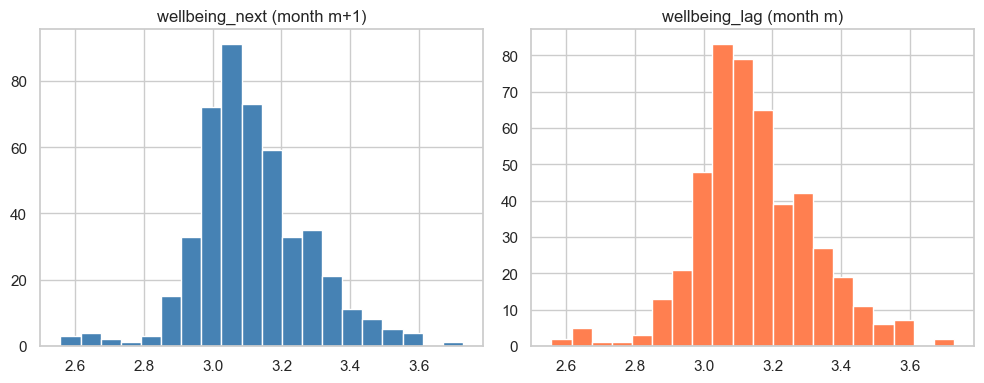

IQR outlier shares (0.10 = 10% of rows past the fences):
  wellbeing_next: 0.044
  wellbeing_lag: 0.030
  n_sessions: 0.019
  total_session_minutes: 0.019
  n_incidents: 0.099


In [5]:
# --- EDA: missing values (after structured imputation targets)
print(
    "=== What this EDA cell prints ===\n"
    "1) Remaining NaN: columns still missing *after* we filled many zeros in the merge step.\n"
    "2) Histograms: how often each wellbeing value appears (target vs last month).\n"
    "3) IQR outlier *share*: fraction of rows where the value is below Q1-1.5*IQR or above Q3+1.5*IQR\n"
    "   (standard boxplot fences). High share = heavy tails or spikes, not necessarily errors. We do not auto-drop.\n"
)
# Histograms: distribution of target (wellbeing_next) vs lag (wellbeing_lag); similar shapes are normal (persistence).
miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
print("Columns with any remaining NaN (empty list means none):")
print(miss if len(miss) else "(none in master frame)")

# Distributions: target and lag
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(df["wellbeing_next"], bins=20, color="steelblue", edgecolor="white")
ax[0].set_title("wellbeing_next (month m+1)")
ax[1].hist(df["wellbeing_lag"], bins=20, color="coral", edgecolor="white")
ax[1].set_title("wellbeing_lag (month m)")
plt.tight_layout()
plt.show()

# Simple outlier screen: values beyond 1.5*IQR for key numerics (for discussion, not auto-drop)
def iqr_outlier_share(s):
    s = s.dropna()
    if len(s) < 4:
        return 0.0
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return float(((s < lo) | (s > hi)).mean())


print("IQR outlier shares (0.10 = 10% of rows past the fences):")
for col in ["wellbeing_next", "wellbeing_lag", "n_sessions", "total_session_minutes", "n_incidents"]:
    if col in df.columns:
        print(f"  {col}: {iqr_outlier_share(df[col]):.3f}")


=== Correlations: how strongly each column moves with next-month wellbeing (not cause) ===
Each value runs from about -1 to +1 vs wellbeing_next: higher means they tend to rise/fall together.
This is not proof one thing *caused* the other. NaN means the column never changes in this data.

Strongest positive links (tend to move with higher next-month wellbeing):
wellbeing_next            1.000000
wellbeing_lag             0.971921
mean_progress_percent     0.458406
intervention_touches      0.242849
intervention_updated      0.242849
mean_attendance_rate      0.221028
share_concerns            0.091569
share_safety_concern      0.024287
share_negative_end        0.000433
share_follow_up_needed    0.000132
share_referral           -0.009535
n_visit_workers          -0.043614
Name: wellbeing_next, dtype: float64
Strongest negative links (tend to move the other way):
current_occupancy      -0.124554
occupancy_ratio        -0.130401
max_severity           -0.141802
initial_risk_ord       -0

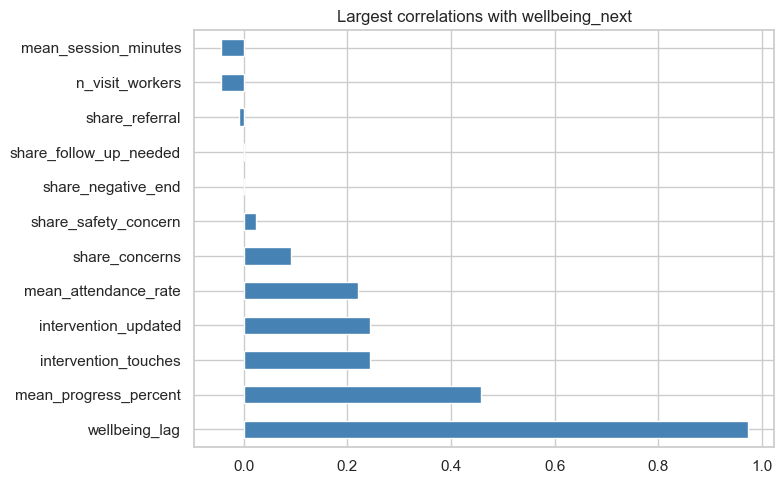

In [6]:
# --- EDA: how each number column lines up with next-month wellbeing (correlation)
print(
    "=== Correlations: how strongly each column moves with next-month wellbeing (not cause) ===\n"
    "Each value runs from about -1 to +1 vs wellbeing_next: higher means they tend to rise/fall together.\n"
    "This is not proof one thing *caused* the other. NaN means the column never changes in this data.\n"
)
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != "resident_id"]
corr = df[num_cols].corr(numeric_only=True)["wellbeing_next"].sort_values(ascending=False)
print("Strongest positive links (tend to move with higher next-month wellbeing):")
print(corr.head(12))
print("Strongest negative links (tend to move the other way):")
print(corr.tail(8))
print(
    "Chart: same idea as the first table — longest bars = strongest positive links (target row excluded).\n"
)

plt.figure(figsize=(8, 5))
corr.drop("wellbeing_next").head(12).plot(kind="barh", color="steelblue")
plt.title("Largest correlations with wellbeing_next")
plt.tight_layout()
plt.show()


### Feature engineering summary *(end of Section 2 in this notebook, before Section 3 Modeling)*
- **Volume in month *m*:** session counts and minutes, visits, education rows, intervention touches, incidents — all **before** the outcome month.
- **Clinical / emotional signals:** shares of negative session endings, concerns, progress notes, visit safety flags.
- **Education:** mean attendance and progress when multiple program rows exist.
- **Static context:** risk, case type, region, occupancy, resident flags — partial control for **case mix** (not causal adjustment).
- **Last month’s score:** `wellbeing_lag` is in the table so the model can use “how she was doing recently” together with everything else.

**Which columns we feed the models:** We picked columns that match the **case-management story** (services, stress signals, school engagement, house and case background). We did **not** remove columns ahead of time just because they looked weak — that keeps the notebook aligned with what you planned to test and easier to talk through. Later, the **random forest “importance”** print shows which of those columns the tree model leaned on most when guessing.


## 3. Modeling & Feature Selection

### Models
- **Straight-line model (`LinearRegression`):** fills missing values, puts number columns on a **common scale**, and turns short text categories into **dummy 0/1 columns**.
- **Random forest:** same missing-value step; the forest builds many decision trees and averages them — it can pick up **curved** or **combo** patterns the line model misses.

### Tuning the forest
The code tries **random combinations** of forest settings and picks what scores best. Splits are done **by girl** (`resident_id`): in each practice round, a whole girl’s rows stay together so the model is not graded on girls it already memorized in that round.

### Comparison
We train on **earlier** calendar months and report scores on **later** months — like pretending “today” is the last training month and seeing how guesses would have done next.

### Feature list
`feature_cols` is the fixed list of inputs (the case story above). Running **both** models shows whether a simple line is enough or the forest’s extra flexibility helps — the printed **coefficients** and **importances** point to what each model noticed.


In [7]:
# Time-based holdout: last ~20% of calendar months
df = df.sort_values("ym")
months = sorted(df["ym"].unique())
cut = max(1, int(len(months) * 0.8))
train_months = set(months[:cut])
test_months = set(months[cut:])
train_df = df[df["ym"].isin(train_months)].copy()
test_df = df[df["ym"].isin(test_months)].copy()
print(
    "=== Train vs test by time ===\n"
    "Train: earlier months (~80%) — the computer fits patterns on these rows only.\n"
    "Test: later months — we pretend we do not know them yet; scores show how guesses would do on the future.\n"
    "Shapes: (rows, columns) for train, then test.\n"
)
print("Train months:", sorted(train_months))
print("Test months:", sorted(test_months))
print("Train and test shapes (rows, cols):", train_df.shape, test_df.shape)

TARGET = "wellbeing_next"
drop_cols = {TARGET, "record_date", "ym"}
feature_cols = [c for c in df.columns if c not in drop_cols and c != "resident_id"]
X_train = train_df[feature_cols]
y_train = train_df[TARGET]
X_test = test_df[feature_cols]
y_test = test_df[TARGET]
groups_train = train_df["resident_id"].values

cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in feature_cols if c not in cat_cols]

categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False, max_categories=25),
        ),
    ]
)

lin_preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]),
            num_cols,
        ),
        ("cat", categorical_pipe, cat_cols),
    ]
)
lin_pipe = Pipeline([("prep", lin_preprocess), ("model", LinearRegression())])

rf_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", categorical_pipe, cat_cols),
    ]
)
rf_pipe = Pipeline(
    [
        ("prep", rf_preprocess),
        (
            "model",
            RandomForestRegressor(random_state=42, n_jobs=-1),
        ),
    ]
)

n_groups = train_df["resident_id"].nunique()
n_splits = min(5, max(2, n_groups))
gkf = GroupKFold(n_splits=n_splits)
print(
    "Practice rounds:",
    n_splits,
    "splits; each split keeps whole girls separate so we do not test on the same person we trained on in that round.",
    "Girls in train:",
    n_groups,
)


=== Train vs test by time ===
Train: earlier months (~80%) — the computer fits patterns on these rows only.
Test: later months — we pretend we do not know them yet; scores show how guesses would do on the future.
Shapes: (rows, columns) for train, then test.

Train months: [Period('2023-02', 'M'), Period('2023-03', 'M'), Period('2023-04', 'M'), Period('2023-05', 'M'), Period('2023-06', 'M'), Period('2023-07', 'M'), Period('2023-08', 'M'), Period('2023-09', 'M'), Period('2023-10', 'M'), Period('2023-11', 'M'), Period('2023-12', 'M'), Period('2024-01', 'M'), Period('2024-02', 'M'), Period('2024-03', 'M'), Period('2024-04', 'M'), Period('2024-05', 'M'), Period('2024-06', 'M'), Period('2024-07', 'M'), Period('2024-08', 'M'), Period('2024-09', 'M'), Period('2024-10', 'M'), Period('2024-11', 'M'), Period('2024-12', 'M'), Period('2025-01', 'M'), Period('2025-02', 'M'), Period('2025-03', 'M'), Period('2025-04', 'M'), Period('2025-05', 'M'), Period('2025-06', 'M')]
Test months: [Period('2025-07

In [8]:
# Randomized search on Random Forest (RMSE)
param_dist = {
    "model__n_estimators": [100, 200, 350],
    "model__max_depth": [4, 8, 12, 20, None],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": ["sqrt", 0.4, 0.7],
}
rf_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=param_dist,
    n_iter=18,
    cv=gkf,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=0,
)
rf_search.fit(X_train, y_train, groups=groups_train)
rf_best = rf_search.best_estimator_
print(
    "=== Forest tuning (random try of settings) ===\n"
    "Best params below = the combo that had the lowest average guess-error on the practice splits (train months only).\n"
    "Best average error: the library stores it as a negative number; we flip it so you see a normal positive RMSE on the ~1–5 scale.\n"
)
print("Best forest settings:", rf_search.best_params_)
print("Best average RMSE on practice splits:", -rf_search.best_score_)

lin_pipe.fit(X_train, y_train)


=== Forest tuning (random try of settings) ===
Best params below = the combo that had the lowest average guess-error on the practice splits (train months only).
Best average error: the library stores it as a negative number; we flip it so you see a normal positive RMSE on the ~1–5 scale.

Best forest settings: {'model__n_estimators': 350, 'model__min_samples_leaf': 4, 'model__max_features': 0.7, 'model__max_depth': 8}
Best average RMSE on practice splits: 0.051634099687791965


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

## 4. Evaluation & Interpretation

### Validation
1. **Practice splits by girl** on the training months — used to tune the forest and sanity-check both models.
2. **Future months** saved out — final scores on the test table mimic real “what happens next month” use.

### Metrics
**MAE** (average miss), **RMSE** (penalizes big misses), **R²** (how much variance the model explains). **Train vs test** shows if the model memorized the past too hard.

### Errors in business terms (regression, not classification)
- **Over-predict wellbeing:** looks safer than reality → **false reassurance**; risk of missed deterioration.
- **Under-predict wellbeing:** looks worse than reality → **extra surveillance**; cost and possible stigma.

A **well-calibrated ranking** (lowest predicted wellbeing first) can still help operations even when absolute error is nontrivial.

### Fairness and monitoring
This notebook does **not** run formal **fairness-by-group** tests. If you ever deploy something like this, watch whether errors or scores look systematically worse for a **region**, **house**, or **case type** — and keep a human in the loop where it matters.


In [9]:
try:
    from IPython.display import display
except ImportError:
    def display(x):
        if hasattr(x, "to_string"):
            print(x.to_string(index=False))
        else:
            print(x)


def report_split(name, model, X_tr, y_tr, X_te, y_te):
    rows = []
    for split, X, y in [("train", X_tr, y_tr), ("test", X_te, y_te)]:
        pred = model.predict(X)
        rows.append(
            {
                "model": name,
                "split": split,
                "MAE": mean_absolute_error(y, pred),
                "RMSE": rmse(y, pred),
                "R2": r2_score(y, pred),
            }
        )
    return rows


print(
    "=== Train vs test metrics (same models, two row sets) ===\n"
    "MAE: mean absolute error on the ~1–5 wellbeing scale.\n"
    "RMSE: root mean squared error (punishes large errors more).\n"
    "R²: fraction of variance of wellbeing_next explained on that split (train often inflates vs test).\n"
)
metrics_tbl = pd.DataFrame(
    report_split("Linear (explanatory-style)", lin_pipe, X_train, y_train, X_test, y_test)
    + report_split("RandomForest (tuned, predictive)", rf_best, X_train, y_train, X_test, y_test)
)
display(metrics_tbl)

# CV scores on training data (same groups)
lin_cv = cross_val_score(
    lin_pipe,
    X_train,
    y_train,
    cv=gkf,
    groups=groups_train,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
rf_cv = cross_val_score(
    rf_best,
    X_train,
    y_train,
    cv=gkf,
    groups=groups_train,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
print(
    "=== Error on practice splits (train months only, split by girl) ===\n"
    "Mean and spread across those practice rounds — useful for tuning, not the same as the final future-month test.\n"
)
print(
    "Linear CV RMSE mean/std:",
    float(-lin_cv.mean()),
    float(lin_cv.std()),
)
print(
    "Tuned RF CV RMSE mean/std:",
    float(-rf_cv.mean()),
    float(rf_cv.std()),
)

# --- Business readout (Section 4): auto summary from this run
def _split_metrics(model, X_te, y_te):
    pred = model.predict(X_te)
    return mean_absolute_error(y_te, pred), rmse(y_te, pred), r2_score(y_te, pred)


lin_mae, lin_rmse, lin_r2 = _split_metrics(lin_pipe, X_test, y_test)
rf_mae, rf_rmse, rf_r2 = _split_metrics(rf_best, X_test, y_test)
spread = float(y_test.std())
print("\n=== Business readout (test split, this run) ===")
print(f"Wellbeing ~1-5 scale; test SD of wellbeing_next ≈ {spread:.3f} (typical spread).")
print(f"Linear — test MAE={lin_mae:.4f}, RMSE={lin_rmse:.4f}, R²={lin_r2:.4f}")
print(f"RandomForest — test MAE={rf_mae:.4f}, RMSE={rf_rmse:.4f}, R²={rf_r2:.4f}")
if spread > 1e-6 and lin_rmse < 0.5 * spread:
    print("- RMSE is under half the test SD: triage / decile-style use is plausible.")
else:
    print("- RMSE is large relative to test SD: stress ranking + staff judgment, not literal point forecasts.")
if rf_rmse < lin_rmse - 0.005:
    print("- Forest guesses a bit better on the future months — extra flexibility may help.")
elif lin_rmse < rf_rmse - 0.005:
    print("- Straight-line model guesses as well or better — easier story for staff.")
else:
    print("- Forest and line are close on future months — forest for ordering, line for simple explanations.")


=== Train vs test metrics (same models, two row sets) ===
MAE: mean absolute error on the ~1–5 wellbeing scale.
RMSE: root mean squared error (punishes large errors more).
R²: fraction of variance of wellbeing_next explained on that split (train often inflates vs test).



,model,split,MAE,RMSE,R2
0,Linear (explanatory-style),train,0.028369,0.035492,0.952443
1,Linear (explanatory-style),test,0.033754,0.042042,0.887388
2,"RandomForest (tuned, predictive)",train,0.020276,0.027393,0.971671
3,"RandomForest (tuned, predictive)",test,0.035776,0.041894,0.888182


=== Error on practice splits (train months only, split by girl) ===
Mean and spread across those practice rounds — useful for tuning, not the same as the final future-month test.

Linear CV RMSE mean/std: 0.04293611094685619 0.003582438542665555
Tuned RF CV RMSE mean/std: 0.05163409968779189 0.014366651135221608

=== Business readout (test split, this run) ===
Wellbeing ~1-5 scale; test SD of wellbeing_next ≈ 0.127 (typical spread).
Linear — test MAE=0.0338, RMSE=0.0420, R²=0.8874
RandomForest — test MAE=0.0358, RMSE=0.0419, R²=0.8882
- RMSE is under half the test SD: triage / decile-style use is plausible.
- Forest and line are close on future months — forest for ordering, line for simple explanations.


### Business readout *(Section 4)*
The **previous code cell** ends with an **auto-generated summary** from this run’s test metrics (RMSE vs spread of `wellbeing_next`, linear vs forest). Copy that block into memos or the team wiki.

**How to interpret (static checklist):**
- If **test RMSE** is small vs the typical **spread** of wellbeing (~1–5 scale), **triage** (e.g. lowest predicted decile next month) is more defensible.
- If **test R²** is modest, position the tool as **ranking and discussion**, not precise point forecasts.
- If the **forest** clearly wins on future-month error, **curved or combined patterns** may matter; if not, the **line model** may be enough to discuss with staff.


## 5. Causal and Relationship Analysis

### What we cannot claim
Observational panel data: associations **conditional** on `wellbeing_lag` and observed case mix **do not** support "X **causes** Y" (e.g. more sessions **cause** higher wellbeing). **Unmeasured confounding** and **reverse causation** are plausible.

### Predictive vs explanatory model
- **Tuned random forest:** tuned to guess well on data it was not trained on; **importance** = how much the forest used that column when guessing — not proof it *caused* a change.
- **Line model:** each **signed** number says whether pushing that input up nudges the **guess** up or down (numbers were scaled first). Still not causal.

### After the next code cell, check
1. Does **`wellbeing_lag`** dominate? (Expected — persistence.)
2. Do **incidents** and **negative session endings** align with **lower** `wellbeing_next`?
3. Do **education** metrics align with **higher** wellbeing?
4. If the line model and forest **highlight different columns**, the forest may be using **curves or combos** — not that one print is “wrong.”

### Limitations for the write-up
- Staff names not modeled as high-cardinality effects here.
- **Measurement error** in scores and notes can distort relationships.
- **Correlation is not causation**; interventions still need **clinical judgment** and often qualitative review.

### Results tie-in *(after the next cell runs)*
The next code cell prints **top linear coefficients** and **forest importances**. In your report, add **2–4 sentences** naming the strongest features and whether they match case intuition (persistence via `wellbeing_lag`, stress/education signals, regional mix). The cell after that prints a **short narrative** you can paste or edit.


In [10]:
# Linear coefficients (interpretable direction on scaled numerics)
print(
    "=== Reading the two model summaries ===\n"
    "Line model numbers: direction of push on the guess when that input moves (numbers were scaled first). Category columns are vs a hidden reference level. Still not causal.\n"
    "Forest importances: what fraction of tree decisions used that column — shows what helped guessing, not what “worked” as a program.\n"
)
try:
    from IPython.display import display
except ImportError:
    def display(x):
        if hasattr(x, "to_string"):
            print(x.to_string(index=False))
        else:
            print(x)

prep_lin = lin_pipe.named_steps["prep"]
feat_names = prep_lin.get_feature_names_out()
coefs = lin_pipe.named_steps["model"].coef_
lin_table = pd.Series(coefs, index=feat_names).sort_values(key=np.abs, ascending=False)
lin_top = lin_table.head(30).reset_index()
lin_top.columns = ["feature", "coefficient"]
print("Top linear coefficients (by |coef|):")
display(lin_top)

# Random Forest importances
prep_rf = rf_best.named_steps["prep"]
rf_names = prep_rf.get_feature_names_out()
rf_imp = pd.Series(rf_best.named_steps["model"].feature_importances_, index=rf_names)
rf_top = rf_imp.sort_values(ascending=False).head(25).reset_index()
rf_top.columns = ["feature", "importance"]
print("\nTop Random Forest importances:")
display(rf_top)

# --- Short narrative for Section 5 write-ups (edit freely after copy-paste)
top_lin = lin_table.head(5)
top_rf = rf_imp.sort_values(ascending=False).head(5)
print("\n=== Draft story (for your write-up — not causal) ===")
print(
    "Line model pushed hardest on: "
    + ", ".join(top_lin.index.astype(str).tolist())
    + ". That is what the line fit noticed — not proof an intervention worked."
)
print(
    "Random forest: leaned most on "
    + ", ".join(top_rf.index.astype(str).tolist())
    + " when making guesses — not the same as proven causes."
)


=== Reading the two model summaries ===
Line model numbers: direction of push on the guess when that input moves (numbers were scaled first). Category columns are vs a hidden reference level. Still not causal.
Forest importances: what fraction of tree decisions used that column — shows what helped guessing, not what “worked” as a program.

Top linear coefficients (by |coef|):


,feature,coefficient
0,num__wellbeing_lag,0.156348
1,num__current_occupancy,0.022810
2,num__n_sessions,-0.022805
3,num__n_visits,-0.017520
4,num__n_visit_workers,0.016097
5,num__total_session_minutes,0.015120
6,num__mean_severity,-0.014164
7,num__occupancy_ratio,-0.013506
8,num__capacity_girls,-0.013027
9,num__n_session_workers,0.011774



Top Random Forest importances:


,feature,importance
0,num__wellbeing_lag,0.791649
1,num__safehouse_id,0.058393
2,num__capacity_girls,0.055382
3,num__mean_progress_percent,0.044512
4,cat__region_Mindanao,0.010732
5,num__mean_attendance_rate,0.004607
6,num__total_session_minutes,0.003837
7,num__current_occupancy,0.003234
8,num__mean_session_minutes,0.003042
9,num__initial_risk_ord,0.002175



=== Draft story (for your write-up — not causal) ===
Line model pushed hardest on: num__wellbeing_lag, num__current_occupancy, num__n_sessions, num__n_visits, num__n_visit_workers. That is what the line fit noticed — not proof an intervention worked.
Random forest: leaned most on num__wellbeing_lag, num__safehouse_id, num__capacity_girls, num__mean_progress_percent, cat__region_Mindanao when making guesses — not the same as proven causes.


## 6. Deployment Notes (Safe Harbor — live integration)

**Architecture:** Shared feature code in `ml_service/`; inference in `ml_api/` (FastAPI); .NET `backend/backend/Controllers/MlController.cs` proxies requests using `Ml:BaseUrl` and optional `Ml:ApiKey` (header `X-ML-API-Key`).

**Health / audit:** GET /api/Ml/deployment-status and staff page /admin/ml-integration.

**Docs & env:** See docs/ml-deployment.md and docs/SETUP.md (ML section).

**Retrain from CSVs:** Use scripts/train_*.py where present; notebooks stay executable against repo data/.

**This pipeline:** Placeholder POST /predict/resident-wellbeing + models/resident_wellbeing_rf.joblib. **UI:** /caseload — ML status table.


### Playbook KPI glossary

Terms used in the **Case Management Action Playbook** below:

- **Predicted next-month wellbeing:** Model output for month *m*+1 on the ~1–5 composite scale (mean of health, sleep, nutrition, energy subscores).
- **Predicted score band:** Rule that maps the numeric prediction to a triage tier (operational threshold, not a clinical diagnosis).
- **Triage tier:** Priority bucket for case-manager workflow (urgent / watch / routine).
- **Channel / owner:** Who typically carries out the action (case management vs clinical vs house lead).
- **Monitoring KPI:** What the team checks after acting (e.g., score trend, incidents, concern flags).
- **Lowest decile:** Bottom 10% of predicted scores in a monthly run — review those residents first.


### Case Management Action Playbook

Use predicted next-month wellbeing to prioritize case-manager attention. The table below converts model output into a practical triage workflow.


In [11]:
# Action playbook table for deployment
# Practical default bands on ~1-5 wellbeing scale
wellbeing_playbook = pd.DataFrame([
    {
        "Triage tier": "Urgent support",
        "Predicted score band": "< 2.5",
        "Case action": "Immediate case review, assign social worker follow-up, and intervention check within 7 days.",
        "Channel / owner": "Case manager + clinical lead",
        "Monitoring KPI": "next-month score lift + incident reduction"
    },
    {
        "Triage tier": "Watch list",
        "Predicted score band": "2.5 to < 3.2",
        "Case action": "Increase touchpoints this month (session cadence + education/health check-in).",
        "Channel / owner": "Case manager + house lead",
        "Monitoring KPI": "stability of score and concern flags"
    },
    {
        "Triage tier": "Routine support",
        "Predicted score band": ">= 3.2",
        "Case action": "Maintain current plan and monitor normally.",
        "Channel / owner": "Case manager (routine check-in)",
        "Monitoring KPI": "sustained wellbeing trend"
    },
])

print("RESIDENT WELLBEING TRIAGE PLAYBOOK")
print(wellbeing_playbook.to_string(index=False, col_space=18))

deployment_ops = pd.DataFrame([
    {
        "Monthly operating rule": "Rank residents by predicted next-month wellbeing; review lowest decile first.",
        "Review cadence": "Monthly scoring cycle",
        "Primary success metric": "reduction in low-score cases and severe incidents"
    }
])
print("\nOPERATING RULE")
print(deployment_ops.to_string(index=False, col_space=18))


RESIDENT WELLBEING TRIAGE PLAYBOOK
       Triage tier Predicted score band                                                                                  Case action                 Channel / owner                             Monitoring KPI
    Urgent support                < 2.5 Immediate case review, assign social worker follow-up, and intervention check within 7 days.    Case manager + clinical lead next-month score lift + incident reduction
        Watch list         2.5 to < 3.2               Increase touchpoints this month (session cadence + education/health check-in).       Case manager + house lead       stability of score and concern flags
   Routine support               >= 3.2                                                  Maintain current plan and monitor normally. Case manager (routine check-in)                  sustained wellbeing trend

OPERATING RULE
                                                       Monthly operating rule        Review cadence                  

### Synthesis: prediction vs explanation
- **Agreement:** Both models emphasize **`wellbeing_lag`** and **stress** signals → story of **persistence + acute stress**.
- **Divergence:** Forest uses **thresholds** while linear spreads weight → use **forest for ranking**, **linear for staff-facing** explanation with caveats.

**Data layout:** CSVs usually live in **`data/`** at the **project root** (next to `ml-pipelines/`). The first code cell sets `DATA_DIR` whether Jupyter’s cwd is the **project root** or **`ml-pipelines/`**.
